In [1]:
import os, time, copy, random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import (EfficientNet_B0_Weights, EfficientNet_B1_Weights,
                                EfficientNet_B2_Weights, EfficientNet_B3_Weights)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

/home/mlguest/miniforge3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

device: cuda NVIDIA GeForce RTX 5070 Ti


In [3]:
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(42)

EPOCHS       = 30
IMG_SIZE     = 32
NUM_WORKERS  = 0

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

transform_test = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
test_ds  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

classes = train_ds.classes

In [5]:
class MiniCNN(nn.Module):
    def __init__(self, num_classes=10, emb_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.embedding  = nn.Linear(128, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x, return_embedding=False):
        f = self.features(x).flatten(1)
        e = self.embedding(f)
        return e if return_embedding else self.classifier(e)

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = correct = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

In [7]:
def train_model(model, train_loader, test_loader, epochs=3, lr=3e-4, tag='model'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        tl = tc = tt = 0
        pbar = tqdm(train_loader, desc=f'[{tag}] {epoch+1}/{epochs}')
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            tl += loss.item() * x.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += x.size(0)
            pbar.set_postfix(loss=tl/tt, acc=tc/tt)
        scheduler.step()

        _, val_acc = evaluate(model, test_loader, criterion)
        print(f'[{tag}] epoch {epoch+1}: train_acc={tc/tt:.4f}  val_acc={val_acc:.4f}')
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, best_acc

In [8]:
def build_efficientnet(name='b0', num_classes=10, in_size=32):
    ctor, weights = {
        'b0': (models.efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        'b1': (models.efficientnet_b1, EfficientNet_B1_Weights.DEFAULT),
        'b2': (models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
        'b3': (models.efficientnet_b3, EfficientNet_B3_Weights.DEFAULT),
    }[name]
    m = ctor(weights=weights)

    old_conv = m.features[0][0]
    new_conv = nn.Conv2d(3, old_conv.out_channels, kernel_size=3,
                         stride=1, padding=1, bias=False)
    with torch.no_grad():
        w = old_conv.weight
        if w.shape[-1] != 3:
            w = F.adaptive_avg_pool2d(w, (3, 3))
        new_conv.weight.copy_(w)
    m.features[0][0] = new_conv

    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, num_classes)
    return m

results, trained_models = {}, {}

In [9]:
set_seed(42)
mini = MiniCNN(num_classes=10, emb_dim=128)
mini, acc_mini = train_model(mini, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, tag='MiniCNN')
trained_models['MiniCNN'] = mini
results['MiniCNN'] = acc_mini

[MiniCNN] 1/30: 100%|██████████| 391/391 [00:15<00:00, 24.92it/s, acc=0.448, loss=1.68]


[MiniCNN] epoch 1: train_acc=0.4484  val_acc=0.5300


[MiniCNN] 2/30: 100%|██████████| 391/391 [00:15<00:00, 25.32it/s, acc=0.586, loss=1.43]


[MiniCNN] epoch 2: train_acc=0.5864  val_acc=0.6474


[MiniCNN] 3/30: 100%|██████████| 391/391 [00:15<00:00, 25.50it/s, acc=0.635, loss=1.33]


...

[MiniCNN] epoch 28: train_acc=0.8389  val_acc=0.8466


[MiniCNN] 29/30: 100%|██████████| 391/391 [00:14<00:00, 26.67it/s, acc=0.837, loss=0.934]


[MiniCNN] epoch 29: train_acc=0.8369  val_acc=0.8457


[MiniCNN] 30/30: 100%|██████████| 391/391 [00:14<00:00, 26.81it/s, acc=0.838, loss=0.933]


[MiniCNN] epoch 30: train_acc=0.8384  val_acc=0.8467


In [10]:
# for name in ['b0', 'b1', 'b2', 'b3']:
#     set_seed(42)
#     model = build_efficientnet(name, num_classes=10, in_size=IMG_SIZE)
#     lr = {'b0': 3e-4, 'b1': 2e-4, 'b2': 2e-4, 'b3': 1.5e-4}[name]
#     tag = f'EfficientNet-{name.upper()}'
#     model, acc = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=lr, tag=tag)
#     trained_models[tag] = model
#     results[tag] = acc

In [11]:
for name in ['b0', 'b3']:
    set_seed(42)
    model = build_efficientnet(name, num_classes=10, in_size=IMG_SIZE)
    lr = {'b0': 3e-4,'b3': 1.5e-4}[name]
    tag = f'EfficientNet-{name.upper()}'
    model, acc = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=lr, tag=tag)
    trained_models[tag] = model
    results[tag] = acc

[EfficientNet-B0] 1/30: 100%|██████████| 391/391 [00:21<00:00, 18.18it/s, acc=0.647, loss=1.31]


[EfficientNet-B0] epoch 1: train_acc=0.6466  val_acc=0.8322


[EfficientNet-B0] 2/30: 100%|██████████| 391/391 [00:23<00:00, 16.69it/s, acc=0.805, loss=0.952]


[EfficientNet-B0] epoch 2: train_acc=0.8054  val_acc=0.8789


[EfficientNet-B0] 3/30: 100%|██████████| 391/391 [00:21<00:00, 18.01it/s, acc=0.846, loss=0.862]


...

[EfficientNet-B3] epoch 28: train_acc=0.9596  val_acc=0.9391


[EfficientNet-B3] 29/30: 100%|██████████| 391/391 [00:33<00:00, 11.56it/s, acc=0.961, loss=0.599]


[EfficientNet-B3] epoch 29: train_acc=0.9607  val_acc=0.9391


[EfficientNet-B3] 30/30: 100%|██████████| 391/391 [00:33<00:00, 11.50it/s, acc=0.958, loss=0.602]


[EfficientNet-B3] epoch 30: train_acc=0.9581  val_acc=0.9394


In [12]:
print('\n=== Точность на тесте ===')
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{k:20s}  acc = {v:.4f}')


=== Точность на тесте ===
EfficientNet-B0       acc = 0.9397
EfficientNet-B3       acc = 0.9394
MiniCNN               acc = 0.8467


In [13]:
@torch.no_grad()
def extract_embeddings(model, loader, model_type='mini'):
    model.eval()
    E, L, I = [], [], []
    for x, y in loader:
        x = x.to(device)
        if model_type == 'mini':
            e = model(x, return_embedding=True)
        else:
            f = model.features(x)
            e = model.avgpool(f).flatten(1)
        E.append(e.cpu()); L.append(y); I.append(x.cpu())
    E = F.normalize(torch.cat(E), dim=1)
    return E, torch.cat(L), torch.cat(I)

mini_embs, mini_labels, mini_imgs = extract_embeddings(mini, test_loader, 'mini')
b0_embs,   b0_labels,   b0_imgs   = extract_embeddings(trained_models['EfficientNet-B0'], test_loader, 'eff')
b3_embs,   b3_labels,   b3_imgs   = extract_embeddings(trained_models['EfficientNet-B3'], test_loader, 'eff')


### Query idx=0, класс = cat


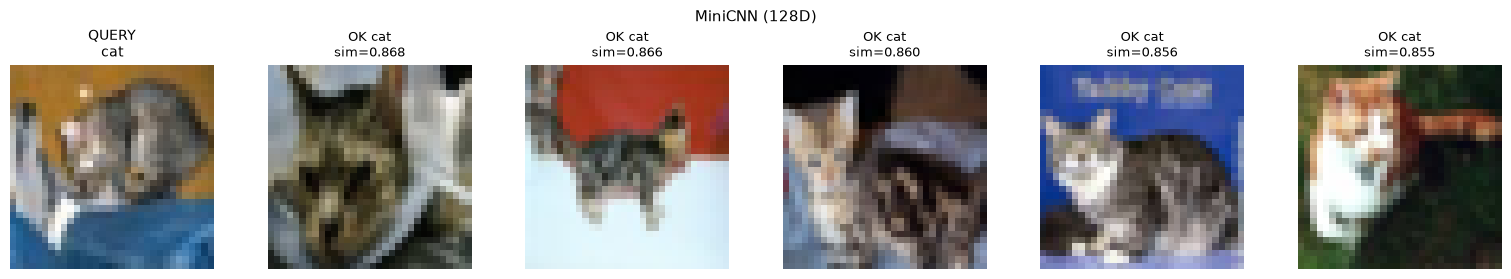

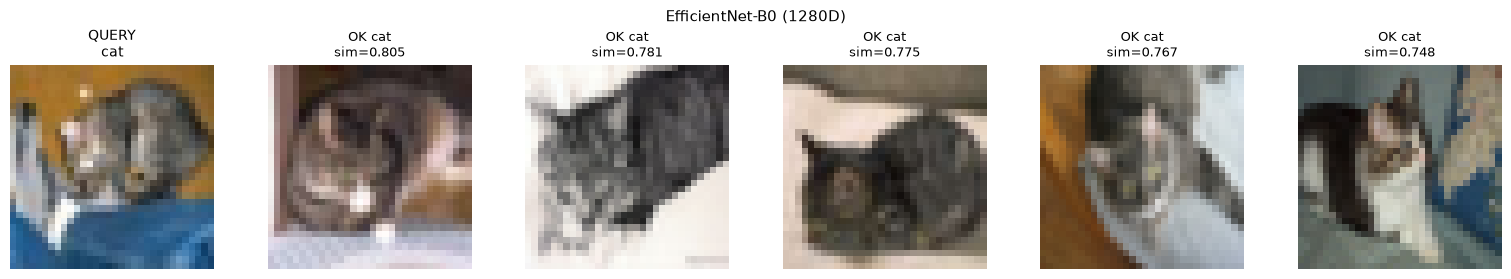

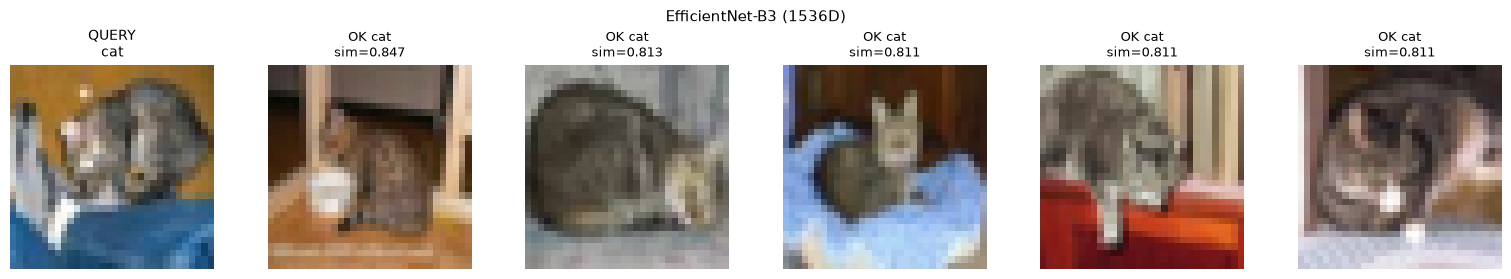


### Query idx=10, класс = airplane


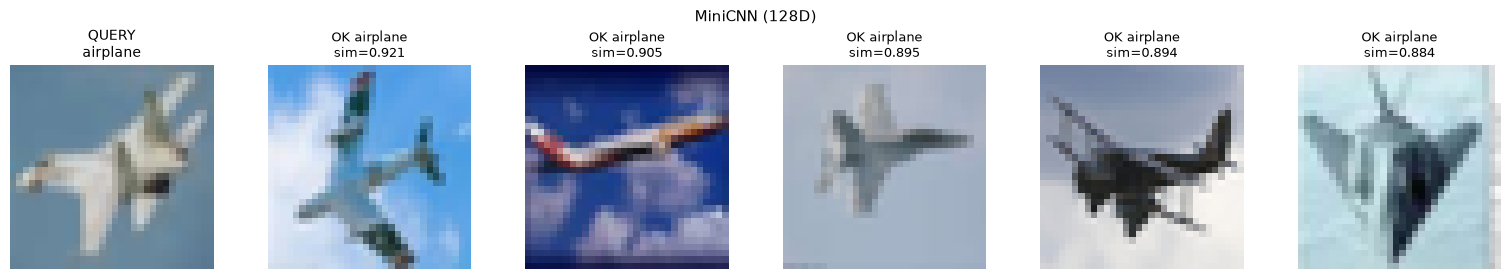

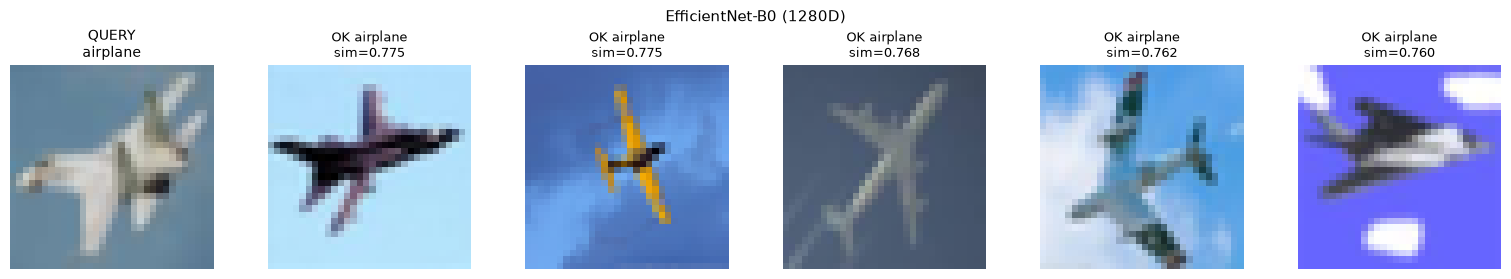

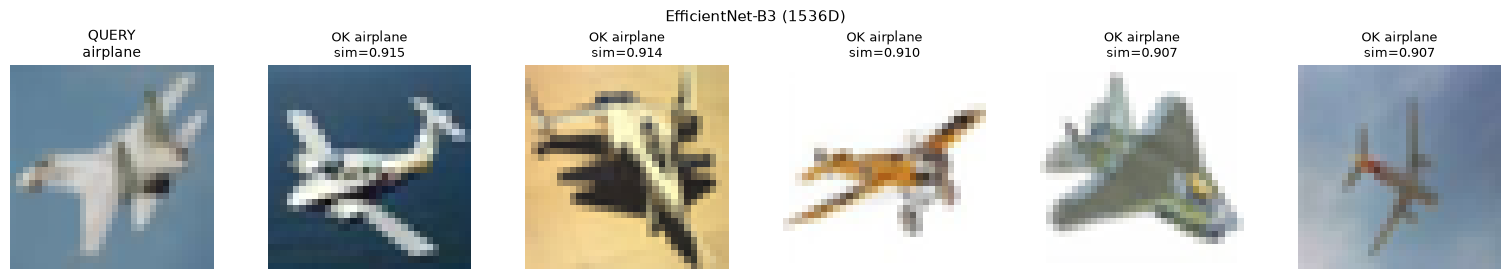


### Query idx=25, класс = bird


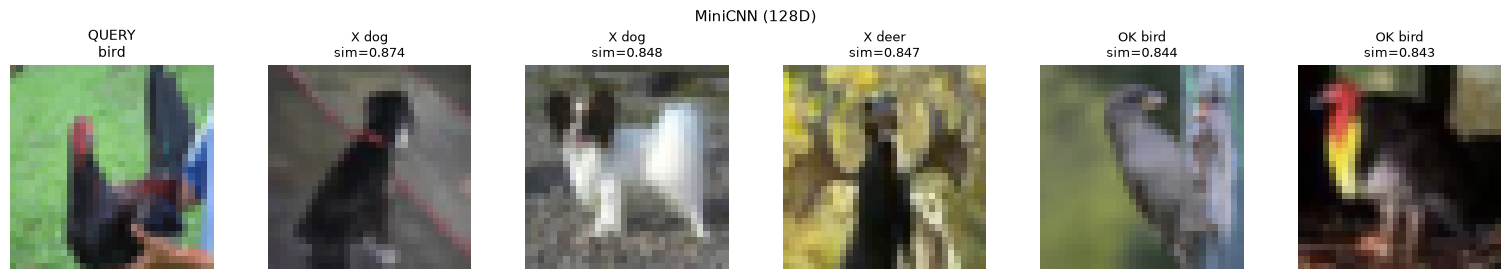

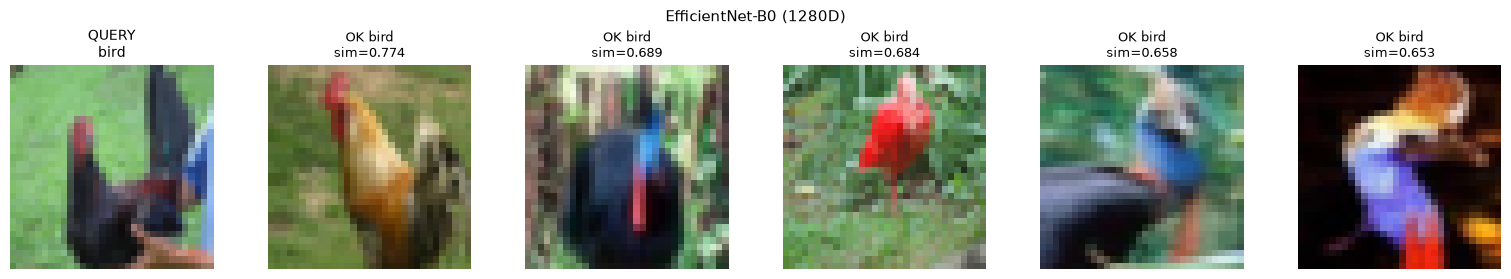

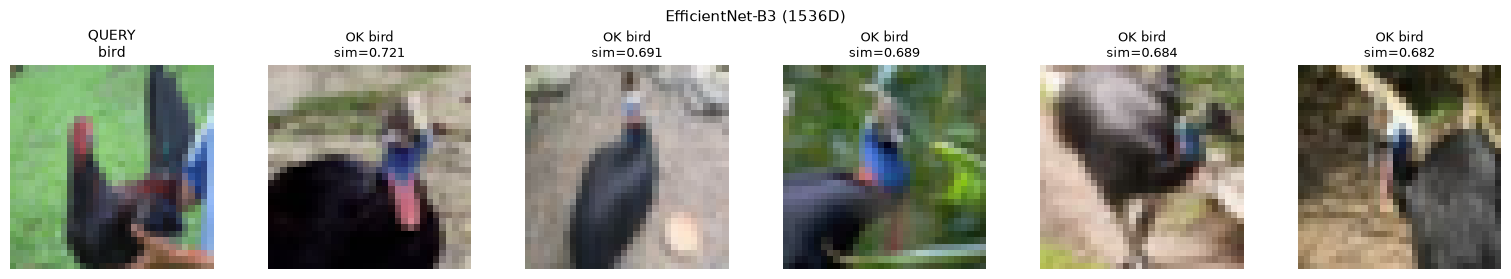

In [14]:
def to_img(t):
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

def show_top5(q_idx, embs, labels, imgs, title, topk=5):
    q = embs[q_idx:q_idx+1]
    sims = (embs @ q.T).squeeze(1)
    sims[q_idx] = -1e9
    top = sims.topk(topk).indices.tolist()

    fig, axes = plt.subplots(1, topk+1, figsize=(2.6*(topk+1), 2.8))
    axes[0].imshow(to_img(imgs[q_idx]))
    axes[0].set_title(f'QUERY\n{classes[labels[q_idx]]}', fontsize=10)
    axes[0].axis('off')
    for i, j in enumerate(top):
        axes[i+1].imshow(to_img(imgs[j]))
        ok = 'OK' if labels[j] == labels[q_idx] else 'X'
        axes[i+1].set_title(f'{ok} {classes[labels[j]]}\nsim={sims[j]:.3f}', fontsize=9)
        axes[i+1].axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

for q_idx in [0, 10, 25]:
    print(f'\n### Query idx={q_idx}, класс = {classes[mini_labels[q_idx]]}')
    show_top5(q_idx, mini_embs, mini_labels, mini_imgs, 'MiniCNN (128D)')
    show_top5(q_idx, b0_embs,   b0_labels,   b0_imgs,   'EfficientNet-B0 (1280D)')
    show_top5(q_idx, b3_embs,   b3_labels,   b3_imgs,   'EfficientNet-B3 (1536D)')

In [15]:
def retrieval_metrics(embs, labels, topk=5):
    sims = embs @ embs.T
    sims.fill_diagonal_(-1e9)
    top = sims.topk(topk, dim=1).indices
    correct = (labels[top] == labels.unsqueeze(1))
    return correct.any(1).float().mean().item(), correct.float().mean().item()

print(f'\n{"Модель":20s} {"top5 hit":>10s} {"prec@5":>10s}')
for name, (e, l) in {
    'MiniCNN':         (mini_embs, mini_labels),
    'EfficientNet-B0': (b0_embs,   b0_labels),
    'EfficientNet-B3': (b3_embs,   b3_labels),
}.items():
    h, p = retrieval_metrics(e, l, topk=5)
    print(f'{name:20s} {h:10.4f} {p:10.4f}')


Модель                 top5 hit     prec@5
MiniCNN                  0.9271     0.7934
EfficientNet-B0          0.9684     0.9208
EfficientNet-B3          0.9699     0.9249


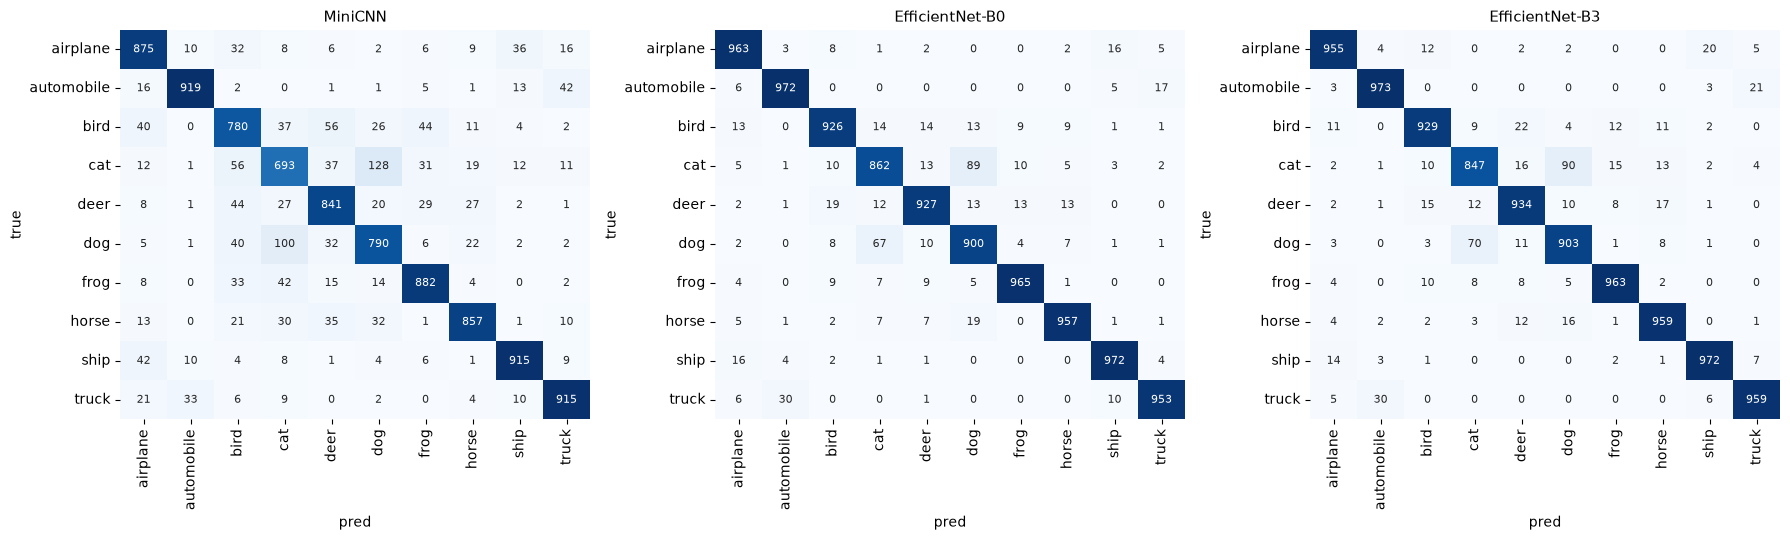

In [16]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    P, L = [], []
    for x, y in loader:
        x = x.to(device)
        P.append(model(x).argmax(1).cpu())
        L.append(y)
    return torch.cat(P).numpy(), torch.cat(L).numpy()

models_dict = {
    'MiniCNN':         trained_models['MiniCNN'],
    'EfficientNet-B0': trained_models['EfficientNet-B0'],
    'EfficientNet-B3': trained_models['EfficientNet-B3'],
}

preds = {name: get_predictions(m, test_loader) for name, m in models_dict.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, (p, l)) in zip(axes, preds.items()):
    cm = confusion_matrix(l, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=False, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()